In [46]:
import os
from pyexpat import features

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = os.path.join("data", "players_data-2025_2026.csv")
df = pd.read_csv(csv_path)

df.describe()

,Rk,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
count,2839.000000,2837.000000,2837.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,...,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000
mean,1420.000000,24.855834,1999.802256,19.138781,13.576611,1218.580134,13.539803,1.660444,1.159211,2.819655,...,2.412821,0.121169,0.041564,14.497710,13.752730,2.060937,21.657978,10.141951,11.924974,0.045791
std,819.693032,4.623789,4.633160,11.520385,11.225366,963.218994,10.703241,2.932688,1.833065,4.134442,...,2.526406,0.352339,0.204853,13.493894,14.665142,3.801657,34.963118,11.810994,12.430342,0.228399
min,1.000000,15.000000,1983.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,710.500000,21.000000,1997.000000,9.000000,3.000000,320.500000,3.600000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,1420.000000,25.000000,2000.000000,20.000000,12.000000,1074.000000,11.900000,0.000000,0.000000,1.000000,...,2.000000,0.000000,0.000000,12.000000,9.000000,1.000000,6.000000,5.000000,8.000000,0.000000
75%,2129.500000,28.000000,2003.000000,29.000000,23.000000,1972.500000,21.900000,2.000000,2.000000,4.000000,...,4.000000,0.000000,0.000000,23.000000,20.000000,2.500000,26.500000,16.000000,19.000000,0.000000
max,2839.000000,41.000000,2010.000000,38.000000,38.000000,3420.000000,38.000000,36.000000,21.000000,41.000000,...,13.000000,3.000000,2.000000,87.000000,118.000000,41.000000,295.000000,77.000000,72.000000,2.000000


Fase 1: Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)
Creen un Jupyter Notebook nuevo, carguen el dataset proporcionado en GitHub y seleccionen a su "Jugador Estrella" (puede ser el jugador con más goles o su favorito del dataset, la decisión es suya). \
\
Creen un vector para su jugador estrella y otro vector para el resto de los candidatos.\
\
Pregunta de control: Antes de medir cualquier distancia, ¿qué operación de la Unidad II deben aplicarle obligatoriamente a estas 4 columnas para que los Minutos_Jugados (rango en miles) no aplasten matemáticamente a los Goles (rango en decenas)? Apliquen esa transformación en el código.

## Respuesta:
La operacion que se debe de aplicar obligatoriamente es Normalizacion ya sea con la estandarizacion del Z-Score o Escalamiento Min-Max

In [47]:
player_col = 'Player'

features = [
    'Min',
    'Gls',
    'Ast',
    'Sh/90',
    'SoT/90',
    'Int'
]

for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f"Matriz de caracteristicas definida con p = {len(features)} dimensiones")
df[[player_col] + features]

Matriz de caracteristicas definida con p = 6 dimensiones


,Player,Min,Gls,Ast,Sh/90,SoT/90,Int
0,Brenden Aaronson,2449,4,5,1.73,0.62,17
1,Jerome Abbey,17,0,0,0.00,0.00,1
2,Zach Abbott,164,0,0,0.00,0.00,2
3,Jones El-Abdellaoui,681,2,0,2.25,0.53,3
4,Himad Abdelli,138,0,0,2.61,0.65,2
...,...,...,...,...,...,...,...
2834,Martín Zubimendi,2992,5,1,0.81,0.27,39
2835,Martin Ødegaard,1369,1,6,1.45,0.53,7
2836,Luka Đurić,10,0,0,0.00,0.00,0
2837,Milan Đurić,386,0,1,2.33,1.17,0


Misión:
Construyan la matriz multidimensional X seleccionando al menos 4 características numéricas (pueden ser más) continuas (float) que definan el rendimiento del jugador (por ejemplo: Goles, Asistencias, Minutos_Jugados, Precisión_Pases, Recuperaciones, etc.). \

In [48]:
df_scaled = (df[features] - df[features].mean()) / df[features].std()

star_name = "Harry Kane"
star_idx = df[df[player_col] == star_name].index

if len(star_idx) == 0:
    star_idx = df.sort_values(by= 'Gls', ascending=False).index[:1]
    star_name = df.loc[star_idx[0], player_col]

star_vector = df_scaled.loc[star_idx[0], features].values

print(f"Vector Estandarizado Z-Score: {star_name}")

for col, val in zip(features, star_vector):
    print(f"{col}: {val}")


Vector Estandarizado Z-Score: Harry Kane
Min: 1.2026547163020314
Gls: 11.709243425100782
Ast: 2.095283005400214
Sh/90: 1.29562107728776
SoT/90: 2.9934211604592953
Int: -0.1813523421320081


Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)
La distancia euclidiana (la línea recta) no es la única forma de viajar por el espacio vectorial. Existen otras métricas como la Distancia Manhattan (Norma L1), que calcula la distancia moviéndose estrictamente en ángulos rectos, como si un taxi navegara por las cuadras de Nueva York, también es conocida como la distancia del taxista. \
\
Misión:
Investiguen y escriban en su Notebook la fórmula matemática de la Distancia Manhattan.
Programen una celda para encontrar al jugador más similar a su estrella usando la Distancia Euclidiana. Impriman el nombre del reemplazo sugerido.\
\
En la siguiente celda, busquen al reemplazo calculando la Distancia Manhattan (deberán generar una función custom para calcular esta distancia).\
\
Análisis Crítico: ¿El algoritmo sugirió al mismo jugador en ambos casos? Como ingenieros, expliquen en un bloque de Markdown las diferencias observables entre la Distancia Euclidiana comparado con la Distancia Manhattan.

## Respuesta:
-**La Distancia Euclidiana castiga los extremos por culpa de los cuadrados.**
Euclidiana busca a alguien que tenga picos de rendimiento casi identicos en las variables clave para no comerse penalizaciones cuadraticas, por eso eligio a Haaland, que se encuentra en un mismo nivel en base a las caracteristicas principales de Kane.\
\
-**Manhattan suma parejo sin exagerar.**
Manhattan busac al que en la suma total de todas las caracteristicas del juego tenga menos distancia acumulada, por eso en el modelo se elige a Mbappe que compensa mejor en el paquete completo de las features elegidas.\



In [49]:
def custom_manhattan_distance(u, v):
    return np.sum(np.abs(u - v))

X_matrix = df_scaled[features].values

eucl_distance = np.sqrt(np.sum((X_matrix - star_vector)**2, axis=1))

manhattan_distance = np.array([custom_manhattan_distance(row, star_vector) for row in X_matrix])

df_res = df.copy()
df_res['Dis_Euclidean'] = eucl_distance
df_res['Manhattan_Distance'] = manhattan_distance

candidates = df_res[df_res[player_col] != star_name]

clone_euclidean = candidates.sort_values(by='Dis_Euclidean').iloc[0]
clone_manhattan = candidates.sort_values(by='Manhattan_Distance').iloc[0]

print(f"Scouting: \n ")
print(f"Jugador Estrella: {star_name} \n")
print(f"Jugador Euclidean: \n{clone_euclidean} \n")
print(f"Jugador Manhattan: \n{clone_manhattan} \n")

Scouting: 
 
Jugador Estrella: Harry Kane 

Jugador Euclidean: 
Rk                               1105
Player                 Erling Haaland
Nation                         no NOR
Pos                                FW
Squad                 Manchester City
                           ...       
Int                                 4
TklW                                7
OG                                  0
Dis_Euclidean                3.705751
Manhattan_Distance           6.959343
Name: 1104, Length: 104, dtype: object 

Jugador Manhattan: 
Rk                             1702
Player                Kylian Mbappé
Nation                       fr FRA
Pos                              FW
Squad                   Real Madrid
                          ...      
Int                               3
TklW                              1
OG                                0
Dis_Euclidean              3.822202
Manhattan_Distance         5.136953
Name: 1701, Length: 104, dtype: object 



Fase 3: El Reto de Visualización en 4D (Investigación Independiente)
El director técnico quiere ver un reporte visual de por qué el jugador que sugirieron es el más parecido al original. \
\
El problema físico es que ustedes seleccionaron 4 (o más) características. Los seres humanos solo podemos ver un eje X, un eje Y y un eje Z.\
\
Misión de Investigación:
Investiguen y elijan una técnica o librería en Python que les permita proyectar visualmente vectores de 4 dimensiones o más en una pantalla 2D.(Pistas que pueden investigar: Gráficos de Radar / Spider Charts, Coordenadas Paralelas, o el uso de color/tamaño como cuartas dimensiones en un Scatter 3D). \
\
Implementen el código para visualizar a su "Jugador Estrella" junto al "Reemplazo Sugerido" y a un "Tercer Jugador Aleatorio" (para ver el contraste).\
\
Entreguen el Notebook documentado comprobando visualmente que los vectores de su estrella y su clon están, efectivamente, muy cerca en el hiperespacio.

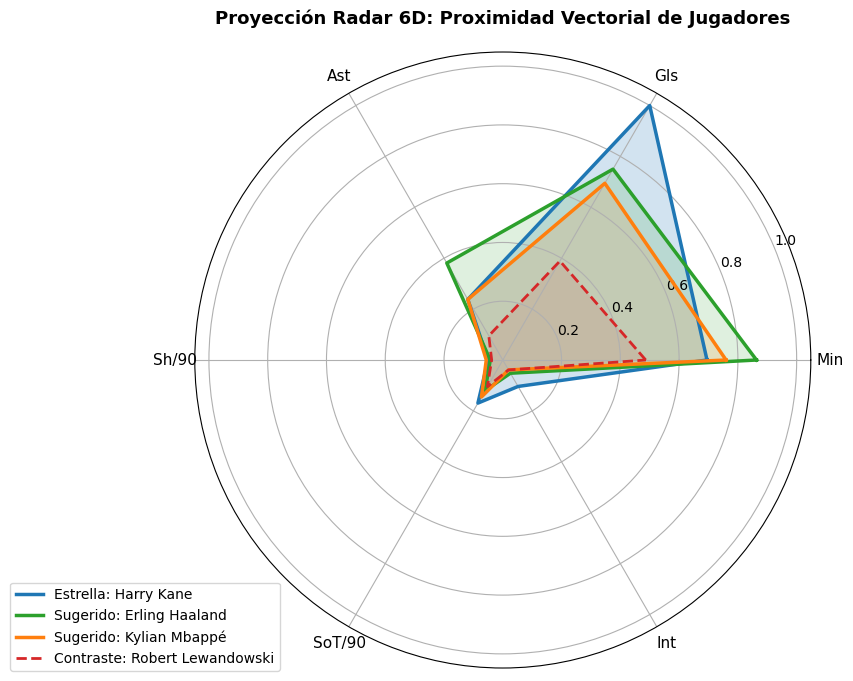

In [53]:
df_minmax = (df[features] - df[features].min()) / (df[features].max() - df[features].min())

contrast_name = "Robert Lewandowski" if "Robert Lewandowski" in df[player_col].values else candidates.iloc[-1][player_col]
contrast_idx = df[df[player_col] == contrast_name].index[0]

eucl_clone_idx = df[df[player_col] == clone_euclidean[player_col]].index[0]
manh_clone_idx = df[df[player_col] == clone_manhattan[player_col]].index[0]

star_i = star_idx[0] if isinstance(star_idx, pd.Index) else star_idx

N = len(features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

vals_star = df_minmax.loc[star_i, features].values.tolist() + [df_minmax.loc[star_i, features].values[0]]
vals_clone_eucl = df_minmax.loc[eucl_clone_idx, features].values.tolist() + [df_minmax.loc[eucl_clone_idx, features].values[0]]
vals_clone_manh = df_minmax.loc[manh_clone_idx, features].values.tolist() + [df_minmax.loc[manh_clone_idx, features].values[0]]
vals_contrast = df_minmax.loc[contrast_idx, features].values.tolist() + [df_minmax.loc[contrast_idx, features].values[0]]

plt.xticks(angles[:-1], features, color='black', size=11)

ax.plot(angles, vals_star, linewidth=2.5, label=f'Estrella: {star_name}', color='#1f77b4')
ax.fill(angles, vals_star, '#1f77b4', alpha=0.20)

ax.plot(angles, vals_clone_eucl, linewidth=2.5, label=f'Sugerido: {clone_euclidean[player_col]}', color='#2ca02c')
ax.fill(angles, vals_clone_eucl, '#2ca02c', alpha=0.15)

ax.plot(angles, vals_clone_manh, linewidth=2.5, label=f'Sugerido: {clone_manhattan[player_col]}', color='#ff7f0e')
ax.fill(angles, vals_clone_manh, '#ff7f0e', alpha=0.15)

ax.plot(angles, vals_contrast, linewidth=2.0, linestyle='--', label=f'Contraste: {contrast_name}', color='#d62728')
ax.fill(angles, vals_contrast, '#d62728', alpha=0.10)

plt.title(f"Proyección Radar {N}D: Proximidad Vectorial de Jugadores", size=13, pad=20, weight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(0.15, 0.15))
plt.show()

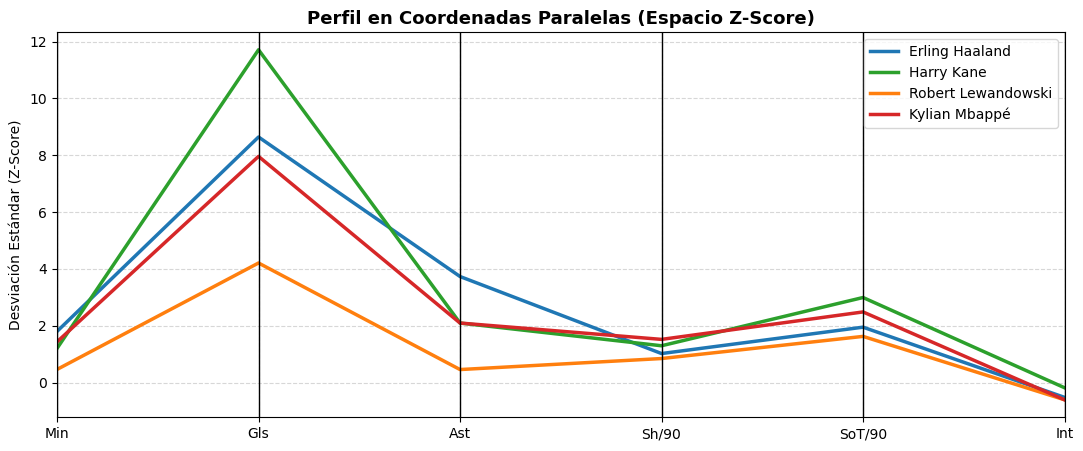

In [54]:
df_viz = df_scaled.copy()
df_viz[player_col] = df[player_col]

players_to_show = [star_name, clone_euclidean[player_col], clone_manhattan[player_col], contrast_name]
df_subset = df_viz[df_viz[player_col].isin(players_to_show)]

plt.figure(figsize=(13, 5))

pd.plotting.parallel_coordinates(df_subset, player_col, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'], linewidth=2.5)
plt.title("Perfil en Coordenadas Paralelas (Espacio Z-Score)", size=13, weight='bold')

plt.ylabel("Desviación Estándar (Z-Score)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Respuesta:
